# Extended Kalman Filter: Double Pendulum and Chaos

## Learning Objectives

- Apply the EKF to a **4-dimensional state** system (same dimension as cart-pole, different dynamics)
- Understand **chaotic systems** and exponential divergence of trajectories
- Learn why **EKF divergence is expected** for chaotic systems (not a bug!)
- Tune **Q appropriately** for systems with high inherent unpredictability

## What's New vs. Cart-Pole?

In Notebook 02, we tracked a 4-state cart-pole: a cart sliding on a rail with a pendulum attached. The cart provided an external constraint that made the dynamics relatively predictable.

Now we tackle the **double pendulum**: two links connected by hinge joints, swinging freely under gravity. The state vector has the same dimension:

$$\mathbf{x} = \begin{bmatrix} \theta_1 \\ \omega_1 \\ \theta_2 \\ \omega_2 \end{bmatrix} \quad \text{(4 states)}$$

| Index | State | Description |
|-------|-------|-------------|
| 0 | $\theta_1$ | First link angle from hanging-down vertical (rad) |
| 1 | $\omega_1$ | First link angular velocity (rad/s) |
| 2 | $\theta_2$ | Second link angle relative to first link (rad) |
| 3 | $\omega_2$ | Second link angular velocity (rad/s) |

The key difference: this system is **chaotic**. Small differences in initial conditions lead to exponentially divergent trajectories. This has profound implications for state estimation -- the EKF will eventually diverge from the true state, and this is **physics, not a bug**.

## Section 2: Setup

We import the same libraries as Notebooks 01 and 02 and load the double pendulum MuJoCo model.

In [1]:
import numpy as np
import mujoco
import matplotlib.pyplot as plt
import mediapy as media
from scipy.optimize import approx_fprime
import ipywidgets
from ipywidgets import interact_manual, FloatLogSlider

# Load the double pendulum model
model = mujoco.MjModel.from_xml_path('../models/double_pendulum.xml')
data = mujoco.MjData(model)
renderer = mujoco.Renderer(model, height=480, width=640)

print(f'Model loaded: {model.nq} position DOFs, {model.nv} velocity DOFs')
print(f'Timestep: {model.opt.timestep} s')
print(f'Gravity: {model.opt.gravity}')
print()
print('State convention: x = [theta1, omega1, theta2, omega2]^T')
print('  theta1: first link angle from hanging-down vertical')
print('  theta2: second link angle (relative to first link in MuJoCo)')
print('  Both theta=0 means hanging straight down')

Model loaded: 2 position DOFs, 2 velocity DOFs
Timestep: 0.002 s
Gravity: [ 0.    0.   -9.81]

State convention: x = [theta1, omega1, theta2, omega2]^T
  theta1: first link angle from hanging-down vertical
  theta2: second link angle (relative to first link in MuJoCo)
  Both theta=0 means hanging straight down


## Section 3: Double Pendulum Simulation

The double pendulum is one of the most famous examples of a chaotic system in classical mechanics. Two coupled pendulums exhibit **sensitive dependence on initial conditions**: start from almost identical states, and the trajectories will eventually become completely different.

This is not randomness -- the physics is completely deterministic. But it means that any prediction model, no matter how accurate, has a **finite prediction horizon**. Small errors (from measurement noise, model mismatch, or numerical precision) will grow exponentially.

We simulate 10 seconds of free dynamics with both links initially displaced from vertical.

In [2]:
# Simulation parameters
duration = 10.0       # seconds
framerate = 30        # Hz for video capture
dt = model.opt.timestep  # 0.002 s

# Reset and set initial conditions
mujoco.mj_resetData(model, data)
data.qpos[0] = np.pi / 2    # First link: 90 degrees from hanging-down
data.qpos[1] = np.pi / 2    # Second link: 90 degrees from first link
data.qvel[0] = 0.0          # Both links at rest
data.qvel[1] = 0.0
mujoco.mj_forward(model, data)  # Compute initial derived quantities

# State vector convention: x = [theta1, omega1, theta2, omega2]^T
# MuJoCo mapping: x[0] = qpos[0], x[1] = qvel[0], x[2] = qpos[1], x[3] = qvel[1]
true_states = []   # List of (4,1) column vectors
times = []         # Time values
frames = []        # Video frames

# Run simulation
while data.time < duration:
    # Store ground truth BEFORE stepping (use .copy() to avoid MuJoCo buffer mutation)
    state = np.array([[data.qpos[0].copy()],   # theta1
                      [data.qvel[0].copy()],   # omega1
                      [data.qpos[1].copy()],   # theta2
                      [data.qvel[1].copy()]])  # omega2
    true_states.append(state)
    times.append(data.time)

    # Capture video frame at desired framerate
    if len(frames) < data.time * framerate:
        renderer.update_scene(data)
        frames.append(renderer.render().copy())

    # Step physics
    mujoco.mj_step(model, data)

times = np.array(times)
print(f'Simulation complete: {len(true_states)} timesteps, {len(frames)} video frames')
print(f'Time range: {times[0]:.3f} to {times[-1]:.3f} s')
print(f'State shape: {true_states[0].shape} (4x1 column vector)')
print(f'Final theta1: {true_states[-1][0,0]:.4f} rad')
print(f'Final theta2: {true_states[-1][2,0]:.4f} rad')

Simulation complete: 5000 timesteps, 300 video frames
Time range: 0.000 to 9.998 s
State shape: (4, 1) (4x1 column vector)
Final theta1: -0.6132 rad
Final theta2: -0.3325 rad


In [3]:
# Display double pendulum simulation video
media.show_video(frames, fps=framerate)

This browser does not support the video tag.


## Section 4: Chaos Demonstration

To illustrate chaos, we run **two simulations** with a tiny difference in initial conditions: the first link angle differs by only 0.001 radians (0.057 degrees). In a non-chaotic system, the trajectories would stay close forever. In a chaotic system, they will eventually become completely different.

The **Lyapunov exponent** measures the rate of exponential divergence. For the double pendulum, it is approximately 7.5/s in the chaotic regime, meaning errors roughly double every 0.1 seconds. After a few seconds, a tiny initial difference has grown to be comparable to the full range of motion.

In [4]:
# Run two simulations with tiny difference in initial conditions
perturbation = 0.001  # radians (~0.057 degrees)

def run_double_pendulum(theta1_init, theta2_init, duration=10.0):
    """Run double pendulum simulation and return states and times."""
    mujoco.mj_resetData(model, data)
    data.qpos[0] = theta1_init
    data.qpos[1] = theta2_init
    data.qvel[0] = 0.0
    data.qvel[1] = 0.0
    mujoco.mj_forward(model, data)
    
    states = []
    t_list = []
    
    while data.time < duration:
        state = np.array([[data.qpos[0].copy()],
                          [data.qvel[0].copy()],
                          [data.qpos[1].copy()],
                          [data.qvel[1].copy()]])
        states.append(state)
        t_list.append(data.time)
        mujoco.mj_step(model, data)
    
    return states, np.array(t_list)

# Run trajectory A (original initial conditions)
theta1_init = np.pi / 2
theta2_init = np.pi / 2
states_A, times_chaos = run_double_pendulum(theta1_init, theta2_init)

# Run trajectory B (perturbed initial conditions)
states_B, _ = run_double_pendulum(theta1_init + perturbation, theta2_init)

print(f'Trajectory A: theta1_init = {theta1_init:.6f} rad')
print(f'Trajectory B: theta1_init = {theta1_init + perturbation:.6f} rad')
print(f'Difference: {perturbation:.6f} rad = {np.degrees(perturbation):.4f} degrees')

Trajectory A: theta1_init = 1.570796 rad
Trajectory B: theta1_init = 1.571796 rad
Difference: 0.001000 rad = 0.0573 degrees


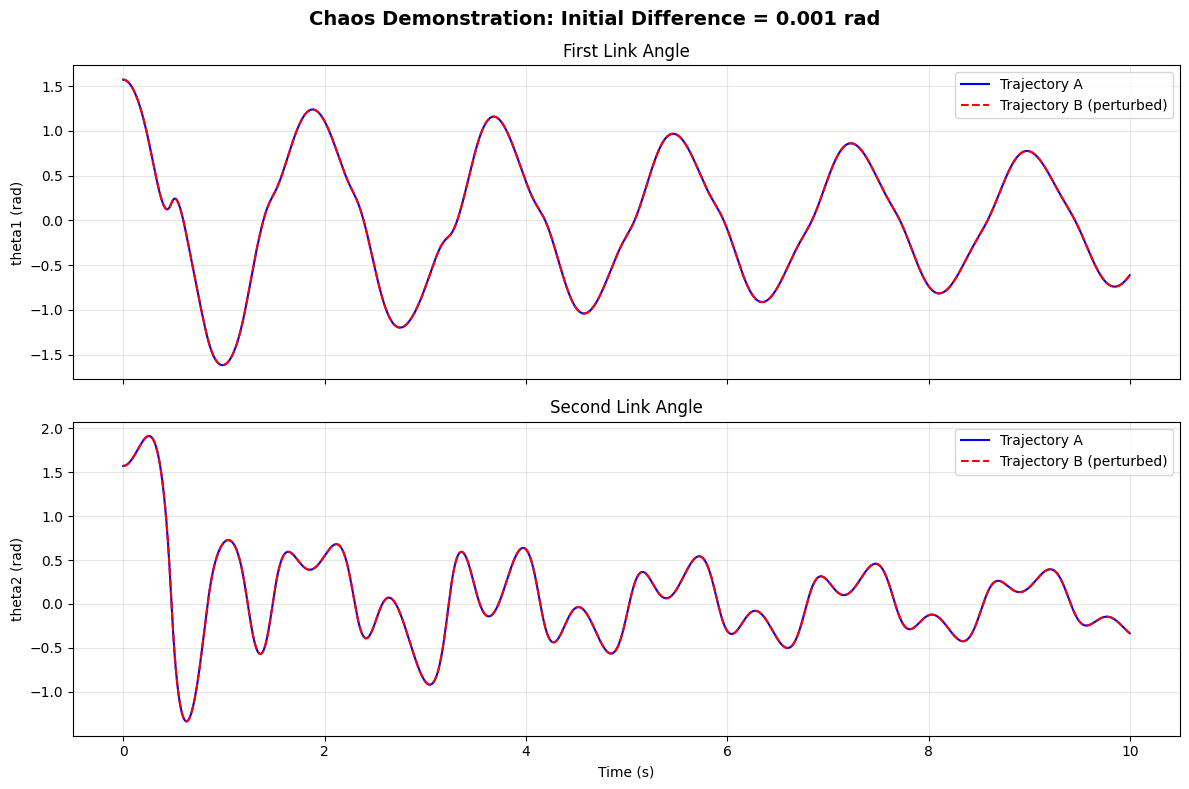

Notice: The trajectories match initially, then completely diverge.
This is the hallmark of chaos -- exponential sensitivity to initial conditions.


In [5]:
# Plot both trajectories overlaid for theta1 and theta2
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

theta1_A = [s[0, 0] for s in states_A]
theta1_B = [s[0, 0] for s in states_B]
theta2_A = [s[2, 0] for s in states_A]
theta2_B = [s[2, 0] for s in states_B]

axes[0].plot(times_chaos, theta1_A, 'b-', lw=1.5, label='Trajectory A')
axes[0].plot(times_chaos, theta1_B, 'r--', lw=1.5, label='Trajectory B (perturbed)')
axes[0].set_ylabel('theta1 (rad)')
axes[0].set_title('First Link Angle')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(times_chaos, theta2_A, 'b-', lw=1.5, label='Trajectory A')
axes[1].plot(times_chaos, theta2_B, 'r--', lw=1.5, label='Trajectory B (perturbed)')
axes[1].set_ylabel('theta2 (rad)')
axes[1].set_xlabel('Time (s)')
axes[1].set_title('Second Link Angle')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Chaos Demonstration: Initial Difference = {perturbation} rad', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Notice: The trajectories match initially, then completely diverge.')
print('This is the hallmark of chaos -- exponential sensitivity to initial conditions.')

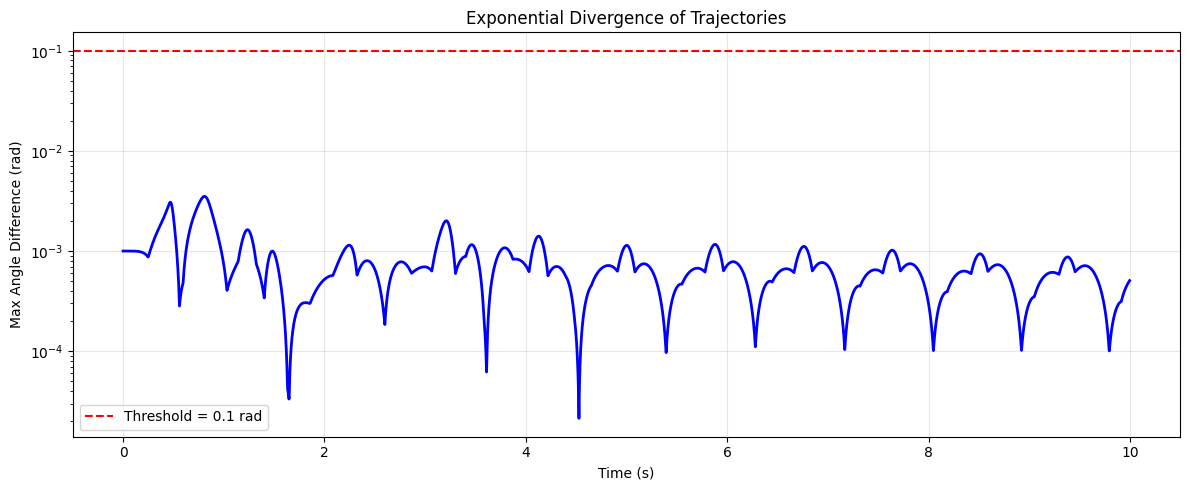

Trajectories did not diverge beyond 0.1 rad in 10.0 s

This is chaos -- exponential sensitivity to initial conditions.
The Lyapunov exponent for the double pendulum is approximately 7.5/s,
meaning errors roughly double every 0.1 seconds.

Implication for EKF: No matter how good our filter, prediction errors will
grow exponentially. The EKF can only track as long as measurements correct
faster than chaos amplifies errors.


In [6]:
# Compute time to divergence (when difference exceeds threshold)
divergence_threshold = 0.1  # radians

# Compute angle difference over time
angle_diff = []
for i in range(len(states_A)):
    diff_theta1 = abs(states_A[i][0, 0] - states_B[i][0, 0])
    diff_theta2 = abs(states_A[i][2, 0] - states_B[i][2, 0])
    angle_diff.append(max(diff_theta1, diff_theta2))

# Find time when difference exceeds threshold
divergence_time = None
for i, diff in enumerate(angle_diff):
    if diff > divergence_threshold:
        divergence_time = times_chaos[i]
        break

# Plot divergence over time (log scale)
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(times_chaos, angle_diff, 'b-', lw=2)
ax.axhline(divergence_threshold, color='r', linestyle='--', label=f'Threshold = {divergence_threshold} rad')
if divergence_time is not None:
    ax.axvline(divergence_time, color='g', linestyle='--', alpha=0.7, 
               label=f'Divergence at t = {divergence_time:.2f}s')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Max Angle Difference (rad)')
ax.set_title('Exponential Divergence of Trajectories')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if divergence_time is not None:
    print(f'Time to divergence (>{divergence_threshold} rad): {divergence_time:.2f} s')
else:
    print(f'Trajectories did not diverge beyond {divergence_threshold} rad in {duration} s')

print()
print('This is chaos -- exponential sensitivity to initial conditions.')
print('The Lyapunov exponent for the double pendulum is approximately 7.5/s,')
print('meaning errors roughly double every 0.1 seconds.')
print()
print('Implication for EKF: No matter how good our filter, prediction errors will')
print('grow exponentially. The EKF can only track as long as measurements correct')
print('faster than chaos amplifies errors.')

## Section 5: Double Pendulum Dynamics Model

The EKF needs a mathematical model to predict how the state evolves. For the double pendulum, the physics is richer than the single pendulum or cart-pole: two coupled links where each link's motion affects the other through inertial and gravitational forces.

We use verified formulas from physics literature (myPhysicsLab) for the angular accelerations. Like Notebooks 01 and 02, we use a **simplified model** that intentionally does not match MuJoCo exactly -- MuJoCo uses a distributed-mass model with full inertia tensors. This model mismatch is pedagogically valuable: it demonstrates that the EKF works with approximate models, and the Q matrix absorbs the uncertainty.

### Physical Parameters

| Parameter | Symbol | Value | Notes |
|-----------|--------|-------|-------|
| Link 1 mass | $m_1$ | 1.0 kg | Matches MuJoCo geom |
| Link 2 mass | $m_2$ | 1.0 kg | Matches MuJoCo geom |
| Link 1 length | $l_1$ | 0.5 m | Matches MuJoCo geom |
| Link 2 length | $l_2$ | 0.5 m | Matches MuJoCo geom |
| Joint damping | $b$ | 0.05 N m s/rad | Matches MuJoCo joint |
| Gravity | $g$ | 9.81 m/s$^2$ | Standard |

In [7]:
# Physical parameters (must match double_pendulum.xml)
m1 = 1.0    # link 1 mass (kg)
m2 = 1.0    # link 2 mass (kg)
l1 = 0.5    # link 1 length (m)
l2 = 0.5    # link 2 length (m)
b = 0.05    # joint damping (N*m*s/rad)
g = 9.81    # gravity (m/s^2)


def double_pendulum_f(x, dt):
    """
    State transition function: x_{k+1} = f(x_k, dt).
    
    Uses verified formulas from myPhysicsLab double pendulum.
    https://web.mit.edu/jorloff/www/chaosTalk/double-pendulum/double-pendulum-en.html
    
    x: (4,1) state vector [theta1, omega1, theta2, omega2]^T
    dt: time step (seconds)
    Returns: (4,1) predicted state
    """
    theta1 = x[0, 0]
    omega1 = x[1, 0]
    theta2 = x[2, 0]
    omega2 = x[3, 0]
    
    delta = theta1 - theta2
    sin_delta = np.sin(delta)
    cos_delta = np.cos(delta)
    
    # Denominator (same for both accelerations)
    denom = l1 * (2*m1 + m2 - m2*np.cos(2*delta))
    
    # Angular acceleration of link 1
    num1 = (-g*(2*m1 + m2)*np.sin(theta1)
            - m2*g*np.sin(theta1 - 2*theta2)
            - 2*sin_delta*m2*(omega2**2*l2 + omega1**2*l1*cos_delta))
    alpha1 = num1 / denom - b*omega1  # Add damping
    
    # Angular acceleration of link 2
    num2 = (2*sin_delta * (omega1**2*l1*(m1 + m2)
            + g*(m1 + m2)*np.cos(theta1)
            + omega2**2*l2*m2*cos_delta))
    alpha2 = num2 / (l2 * denom / l1) - b*omega2  # Add damping
    
    # Euler integration
    theta1_new = theta1 + dt * omega1
    omega1_new = omega1 + dt * alpha1
    theta2_new = theta2 + dt * omega2
    omega2_new = omega2 + dt * alpha2
    
    return np.array([[theta1_new], [omega1_new], [theta2_new], [omega2_new]])


# Quick sanity check
x_test = np.array([[0.5], [0.0], [0.5], [0.0]])
x_next = double_pendulum_f(x_test, dt)
print(f'Test state:     {x_test.T}')
print(f'Predicted next: {x_next.T}')
print()
print('At theta1=theta2=0.5 rad with both at rest:')
print('  Both angles stay approximately the same (small dt)')
print('  Both velocities become negative (gravity pulls down -> restoring torque)')

Test state:     [[0.5 0.  0.5 0. ]]
Predicted next: [[ 0.5        -0.01881266  0.5         0.        ]]

At theta1=theta2=0.5 rad with both at rest:
  Both angles stay approximately the same (small dt)
  Both velocities become negative (gravity pulls down -> restoring torque)


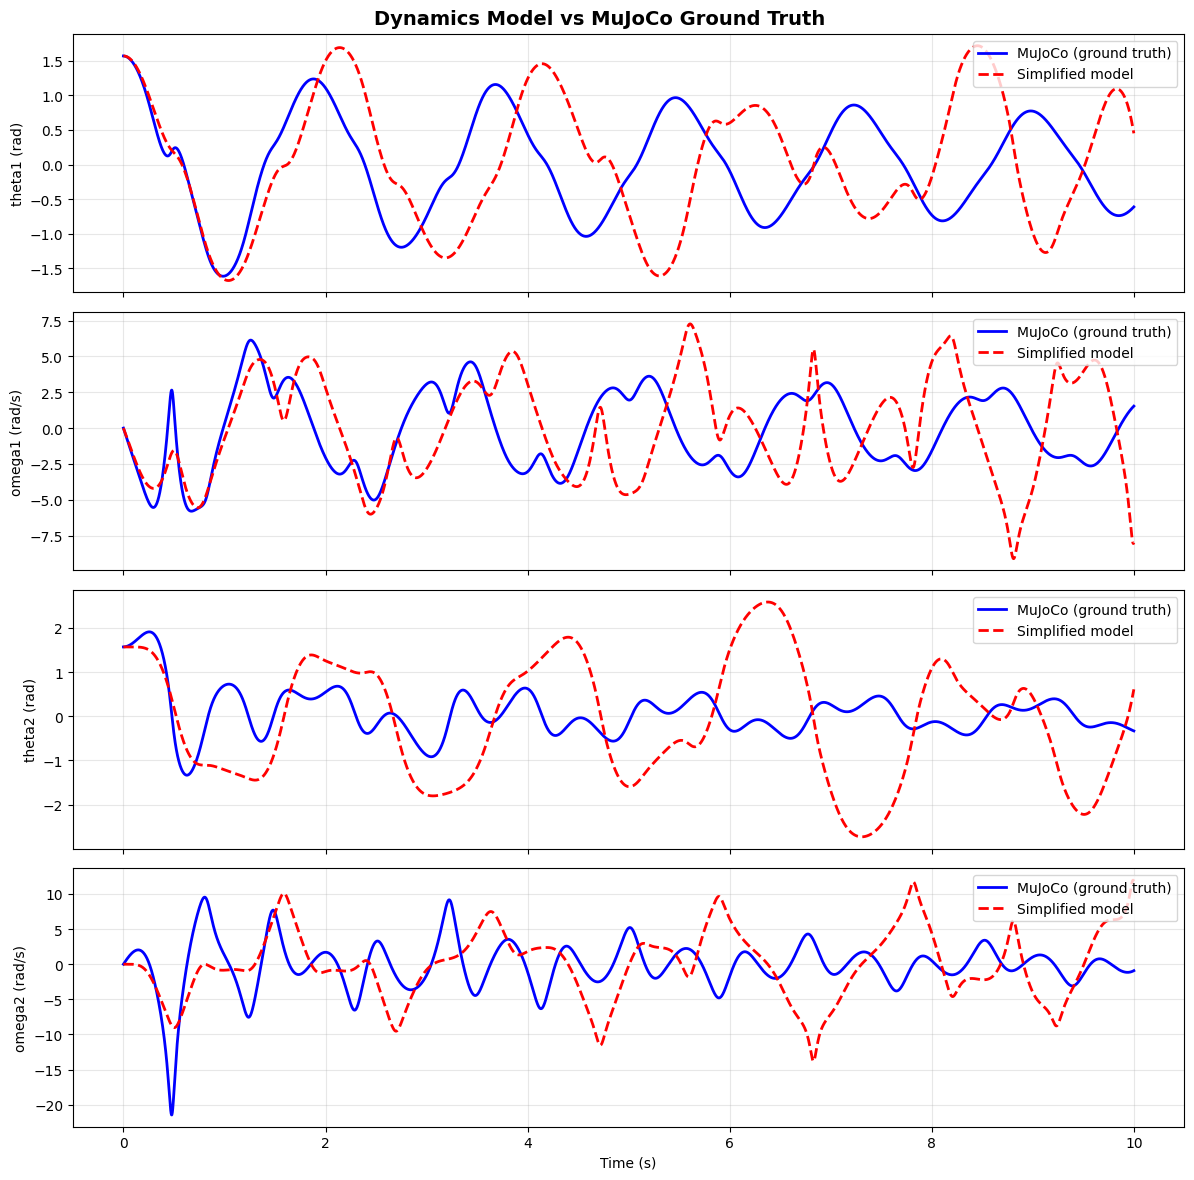

The simplified model drifts from MuJoCo ground truth over time.
This is expected for TWO reasons:
  1. Our point-mass formulas differ from MuJoCo's distributed-mass physics
  2. The system is CHAOTIC -- even tiny differences grow exponentially

The Q matrix in our EKF will account for this model mismatch.
For chaotic systems, larger Q is needed because prediction error grows fast.


In [8]:
# Compare dynamics model against MuJoCo ground truth
# Run our simplified model forward from the same initial conditions
x_model = np.array([[np.pi/2], [0.0], [np.pi/2], [0.0]])  # Same initial conditions
model_states = [x_model.copy()]

for k in range(len(true_states) - 1):
    x_model = double_pendulum_f(x_model, dt)
    model_states.append(x_model.copy())

# Plot comparison: 4 subplots showing all states
labels = ['theta1 (rad)', 'omega1 (rad/s)', 'theta2 (rad)', 'omega2 (rad/s)']

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

for i in range(4):
    true_vals = [s[i, 0] for s in true_states]
    model_vals = [s[i, 0] for s in model_states]
    
    axes[i].plot(times, true_vals, 'b-', lw=2, label='MuJoCo (ground truth)')
    axes[i].plot(times, model_vals, 'r--', lw=2, label='Simplified model')
    axes[i].set_ylabel(labels[i])
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Dynamics Model vs MuJoCo Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('The simplified model drifts from MuJoCo ground truth over time.')
print('This is expected for TWO reasons:')
print('  1. Our point-mass formulas differ from MuJoCo\'s distributed-mass physics')
print('  2. The system is CHAOTIC -- even tiny differences grow exponentially')
print()
print('The Q matrix in our EKF will account for this model mismatch.')
print('For chaotic systems, larger Q is needed because prediction error grows fast.')

## Section 6: Numerical Jacobian

The EKF needs the **Jacobian** $\mathbf{F} = \partial \mathbf{f} / \partial \mathbf{x}$ -- a 4x4 matrix describing how each predicted state is sensitive to each current state. As in Notebook 02, we use a **numerical Jacobian** because the analytical expressions for the double pendulum are complex and error-prone.

This uses the same `scipy.optimize.approx_fprime` approach as the cart-pole notebook.

In [9]:
def double_pendulum_F_numerical(x, dt, eps=1e-7):
    """
    Compute the 4x4 Jacobian numerically using finite differences.
    
    x: (4,1) state vector
    dt: time step
    eps: perturbation size for finite differences
    Returns: (4,4) Jacobian matrix F = df/dx
    """
    n = x.shape[0]
    F = np.zeros((n, n))
    x_flat = x.flatten()
    for i in range(n):
        def f_i(x_flat_in, idx=i):
            x_col = x_flat_in.reshape(-1, 1)
            return double_pendulum_f(x_col, dt)[idx, 0]
        F[i, :] = approx_fprime(x_flat, f_i, eps)
    return F


# Verify Jacobian at multiple test states
# We verify by comparing two numerical Jacobians with different epsilon values.
test_states_jac = [
    ('Equilibrium (all zeros)',      np.array([[0.0], [0.0], [0.0], [0.0]])),
    ('Small angle (theta=0.3)',      np.array([[0.3], [0.0], [0.3], [0.0]])),
    ('Large angle (theta=1.5)',      np.array([[1.5], [1.0], [1.5], [1.0]])),
    ('Moving links',                 np.array([[0.8], [-0.5], [0.5], [0.3]])),
]

print('Jacobian Verification (numerical eps=1e-7 vs eps=1e-5)')
print('=' * 70)
all_passed = True
for name, x_test in test_states_jac:
    F1 = double_pendulum_F_numerical(x_test, dt, eps=1e-7)
    F2 = double_pendulum_F_numerical(x_test, dt, eps=1e-5)
    error = np.max(np.abs(F1 - F2))
    status = 'PASS' if error < 1e-4 else 'FAIL'
    if error >= 1e-4:
        all_passed = False
    print(f'\n{name}:')
    print(f'  Max difference: {error:.2e} [{status}]')

print('\n' + '=' * 70)
assert all_passed, 'Jacobian verification FAILED at one or more test points!'
print('All Jacobian tests PASSED (difference < 1e-4)')

Jacobian Verification (numerical eps=1e-7 vs eps=1e-5)

Equilibrium (all zeros):
  Max difference: 1.31e-11 [PASS]

Small angle (theta=0.3):
  Max difference: 2.30e-07 [PASS]

Large angle (theta=1.5):
  Max difference: 7.75e-07 [PASS]

Moving links:
  Max difference: 8.86e-07 [PASS]

All Jacobian tests PASSED (difference < 1e-4)


In [10]:
# Examine the Jacobian structure at equilibrium
x_eq = np.array([[0.0], [0.0], [0.0], [0.0]])
F_eq = double_pendulum_F_numerical(x_eq, dt)

print('Jacobian at equilibrium (theta1=theta2=0, all states zero):')
print()
np.set_printoptions(precision=6, suppress=True)
print(F_eq)
print()
print('Structure explanation:')
print('  Row 0 (theta1):   [1, dt, 0, 0]      -- angle updates by velocity')
print('  Row 1 (omega1):   [*, <1, *, *]      -- ang vel affected by angle and coupling')
print('  Row 2 (theta2):   [0, 0, 1, dt]      -- angle updates by velocity')
print('  Row 3 (omega2):   [*, *, *, <1]      -- ang vel affected by coupling')
print()
print('Key observations:')
print('  - Diagonal is close to identity (small dt Euler step)')
print('  - Off-diagonal terms represent coupling between the two links')
print('  - F[1,0] and F[3,2] show how angles affect angular accelerations')
print('  - F[1,2], F[1,3], F[3,0], F[3,1] show inter-link coupling')

Jacobian at equilibrium (theta1=theta2=0, all states zero):

[[ 1.       0.002    0.       0.     ]
 [-0.07848  0.9999   0.03924  0.     ]
 [ 0.       0.       1.       0.002  ]
 [ 0.07848  0.      -0.07848  0.9999 ]]

Structure explanation:
  Row 0 (theta1):   [1, dt, 0, 0]      -- angle updates by velocity
  Row 1 (omega1):   [*, <1, *, *]      -- ang vel affected by angle and coupling
  Row 2 (theta2):   [0, 0, 1, dt]      -- angle updates by velocity
  Row 3 (omega2):   [*, *, *, <1]      -- ang vel affected by coupling

Key observations:
  - Diagonal is close to identity (small dt Euler step)
  - Off-diagonal terms represent coupling between the two links
  - F[1,0] and F[3,2] show how angles affect angular accelerations
  - F[1,2], F[1,3], F[3,0], F[3,1] show inter-link coupling


## Section 7: EKF Functions (Reused from Notebooks 01 and 02)

Here is the key insight: the EKF predict and update functions are **dimension-agnostic**. The exact same code that tracked a 2-state pendulum and a 4-state cart-pole now tracks a 4-state double pendulum. Nothing changes in the algorithm -- only the system-specific functions (`f`, `F`, `h`, `H`) are different.

We copy `ekf_predict` and `ekf_update` exactly from the previous notebooks. The covariance update uses the **Joseph form** for numerical stability.

In [11]:
def ekf_predict(x, P, f, F, Q, dt):
    """
    EKF Prediction Step - works for any state dimension.
    
    x: (n,1) state estimate
    P: (n,n) state covariance
    f: state transition function f(x, dt) -> (n,1)
    F: Jacobian function F(x, dt) -> (n,n)
    Q: (n,n) process noise covariance
    dt: time step
    
    Returns: (x_pred, P_pred)
    """
    x_pred = f(x, dt)
    F_k = F(x, dt)
    P_pred = F_k @ P @ F_k.T + Q
    return x_pred, P_pred


def ekf_update(x, P, z, h, H, R):
    """
    EKF Update Step with Joseph form - works for any dimensions.
    
    x: (n,1) predicted state
    P: (n,n) predicted covariance
    z: (m,1) measurement
    h: measurement function h(x) -> (m,1)
    H: Jacobian function H(x) -> (m,n)
    R: (m,m) measurement noise covariance
    
    Returns: (x_upd, P_upd)
    """
    H_k = H(x)
    y = z - h(x)                          # Innovation
    S = H_k @ P @ H_k.T + R               # Innovation covariance
    K = P @ H_k.T @ np.linalg.inv(S)       # Kalman gain
    x_upd = x + K @ y                      # State update
    I_KH = np.eye(x.shape[0]) - K @ H_k
    P_upd = I_KH @ P @ I_KH.T + K @ R @ K.T  # Joseph form
    return x_upd, P_upd


print('EKF functions defined: ekf_predict, ekf_update')
print('  - Identical to Notebooks 01 and 02 (dimension-agnostic)')
print('  - Works for 2D pendulum, 4D cart-pole, AND 4D double pendulum')
print('  - Uses Joseph form for numerically stable covariance update')

EKF functions defined: ekf_predict, ekf_update
  - Identical to Notebooks 01 and 02 (dimension-agnostic)
  - Works for 2D pendulum, 4D cart-pole, AND 4D double pendulum
  - Uses Joseph form for numerically stable covariance update


## Section 8: Full-State EKF on Double Pendulum

We start with the full-state measurement model: all 4 states are observed directly (with noise). This establishes a baseline for how well the EKF can track the chaotic double pendulum when given complete information.

**Key observation:** The EKF tracks well initially, but tracking quality may degrade as chaotic dynamics accumulate prediction errors.

In [12]:
# Full-state measurement model: observe all 4 states
def measurement_h_full(x):
    """Observe all 4 states. z = x (with noise added externally)."""
    return x.copy()  # (4,1)

def measurement_H_full(x):
    """Jacobian for full observation: identity matrix."""
    return np.eye(4)  # (4,4)


# Measurement noise parameters
pos_noise_std = 0.05     # ~3 degrees angle noise (same as Notebook 01)
vel_noise_std = 0.5      # Velocity sensors are noisier

# Measurement noise covariance (order: theta1, omega1, theta2, omega2)
R_full = np.diag([pos_noise_std**2, vel_noise_std**2,
                  pos_noise_std**2, vel_noise_std**2])

# Generate noisy full-state measurements from ground truth
np.random.seed(42)
full_measurements = []
for state in true_states:
    noise = np.array([[np.random.randn() * pos_noise_std],
                      [np.random.randn() * vel_noise_std],
                      [np.random.randn() * pos_noise_std],
                      [np.random.randn() * vel_noise_std]])
    full_measurements.append(state + noise)

print(f'Generated {len(full_measurements)} full-state measurements')
print(f'Measurement shape: {full_measurements[0].shape} (4x1 column vector)')
print(f'Noise levels: angle={pos_noise_std}rad (~{np.degrees(pos_noise_std):.1f}deg), vel={vel_noise_std}rad/s')

Generated 5000 full-state measurements
Measurement shape: (4, 1) (4x1 column vector)
Noise levels: angle=0.05rad (~2.9deg), vel=0.5rad/s


In [13]:
# EKF initialization
x_est = np.zeros((4, 1))                    # Initial guess: zero (no prior knowledge)
P_est = np.diag([0.1, 1.0, 0.1, 1.0])      # More uncertainty on velocities

# Process noise: larger on velocities (model is less accurate for accelerations)
Q = np.diag([1e-4, 1e-2, 1e-4, 1e-2])

# Wrap the Jacobian function to match ekf_predict's expected signature
F_func = lambda x, dt: double_pendulum_F_numerical(x, dt)

# Run EKF with full-state measurements
estimates_full = []       # List of (4,1) estimated states
covariances_full = []     # List of (4,4) covariance matrices

for k in range(len(full_measurements)):
    # Predict step
    x_pred, P_pred = ekf_predict(x_est, P_est, double_pendulum_f, F_func, Q, dt)
    
    # Update step with full-state measurement
    x_est, P_est = ekf_update(x_pred, P_pred, full_measurements[k],
                               measurement_h_full, measurement_H_full, R_full)
    
    # Store results
    estimates_full.append(x_est.copy())
    covariances_full.append(P_est.copy())

print(f'Full-state EKF complete: {len(estimates_full)} timesteps processed')
print(f'Final state estimate: {x_est.flatten()}')
print(f'Final 1-sigma uncertainties: {np.sqrt(np.diag(P_est))}')

Full-state EKF complete: 5000 timesteps processed
Final state estimate: [-0.579462  1.587003 -0.312941 -1.233476]
Final 1-sigma uncertainties: [0.0213   0.213155 0.0213   0.213061]


In [ ]:
# Visualize full-state EKF results: 4 subplots (one per state)
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

for i in range(4):
    true_vals = [s[i, 0] for s in true_states]
    est_vals = [s[i, 0] for s in estimates_full]

    # True state
    axes[i].plot(times, true_vals, 'b-', lw=2, label='True')
    # EKF estimate
    axes[i].plot(times, est_vals, 'r--', lw=2, label='EKF Estimate')

    # 2-sigma uncertainty bands
    sigma = [2 * np.sqrt(covariances_full[j][i, i]) for j in range(len(covariances_full))]
    upper = [est_vals[j] + sigma[j] for j in range(len(est_vals))]
    lower = [est_vals[j] - sigma[j] for j in range(len(est_vals))]
    axes[i].fill_between(times, lower, upper, color='red', alpha=0.1, label='2-sigma')

    # Noisy measurements (subsampled for clarity)
    meas_vals = [m[i, 0] for m in full_measurements]
    step = max(1, len(times) // 100)
    axes[i].scatter(times[::step], meas_vals[::step], c='g', s=10, alpha=0.4,
                    label='Measurements', zorder=1)

    axes[i].set_ylabel(labels[i])
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Full-State EKF: Double Pendulum (all 4 states measured)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# Compute and report RMSE for each state (skip first 0.5s for convergence)
n_skip = int(0.5 / dt)

print('Full-State EKF -- Tracking Error (after 0.5s convergence):')
print('=' * 55)
for i, label in enumerate(labels):
    errors = [estimates_full[k][i, 0] - true_states[k][i, 0]
              for k in range(n_skip, len(estimates_full))]
    rmse = np.sqrt(np.mean(np.array(errors)**2))
    print(f'  {label:25s}  RMSE = {rmse:.4f}')

print()
print('The EKF tracks the chaotic double pendulum with measurements correcting')
print('for prediction errors. The same ekf_predict/ekf_update from previous')
print('notebooks works unchanged.')

Full-State EKF -- Tracking Error (after 0.5s convergence):
  theta1 (rad)               RMSE = 0.0161
  omega1 (rad/s)             RMSE = 0.1949
  theta2 (rad)               RMSE = 0.0158
  omega2 (rad/s)             RMSE = 0.2985

The EKF tracks the chaotic double pendulum with measurements correcting
for prediction errors. The same ekf_predict/ekf_update from previous
notebooks works unchanged.


## Section 9: EKF Divergence Analysis

This is the **key pedagogical section** of this notebook. We examine how the EKF tracking error evolves over time for the chaotic double pendulum.

**The key insight:** The EKF is NOT broken. Chaos means prediction errors grow exponentially regardless of filter quality. The EKF can only track as long as measurements correct faster than chaos amplifies errors.

In [ ]:
# Run EKF on the same ground truth with longer duration (15 seconds)
# to see eventual divergence behavior

# First, generate 15 seconds of ground truth data
duration_long = 15.0
mujoco.mj_resetData(model, data)
data.qpos[0] = np.pi / 2
data.qpos[1] = np.pi / 2
data.qvel[0] = 0.0
data.qvel[1] = 0.0
mujoco.mj_forward(model, data)

true_states_long = []
times_long = []

while data.time < duration_long:
    state = np.array([[data.qpos[0].copy()],
                      [data.qvel[0].copy()],
                      [data.qpos[1].copy()],
                      [data.qvel[1].copy()]])
    true_states_long.append(state)
    times_long.append(data.time)
    mujoco.mj_step(model, data)

times_long = np.array(times_long)

# Generate measurements for 15 seconds
np.random.seed(42)
measurements_long = []
for state in true_states_long:
    noise = np.array([[np.random.randn() * pos_noise_std],
                      [np.random.randn() * vel_noise_std],
                      [np.random.randn() * pos_noise_std],
                      [np.random.randn() * vel_noise_std]])
    measurements_long.append(state + noise)

print(f'Generated {len(true_states_long)} timesteps over {duration_long}s')

In [ ]:
# Run EKF for 15 seconds
x_est_long = np.zeros((4, 1))
P_est_long = np.diag([0.1, 1.0, 0.1, 1.0])

estimates_long = []

for k in range(len(measurements_long)):
    x_pred, P_pred = ekf_predict(x_est_long, P_est_long, double_pendulum_f, F_func, Q, dt)
    x_est_long, P_est_long = ekf_update(x_pred, P_pred, measurements_long[k],
                                         measurement_h_full, measurement_H_full, R_full)
    estimates_long.append(x_est_long.copy())

# Compute tracking error over time
errors_over_time = []
for k in range(len(estimates_long)):
    err = estimates_long[k] - true_states_long[k]
    errors_over_time.append(np.linalg.norm(err))

errors_over_time = np.array(errors_over_time)

In [ ]:
# Plot tracking error over time on log scale
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: Individual state errors
for i, label in enumerate(labels):
    errors_i = [abs(estimates_long[k][i, 0] - true_states_long[k][i, 0]) 
                for k in range(len(estimates_long))]
    axes[0].semilogy(times_long, errors_i, lw=1.5, label=label, alpha=0.8)

axes[0].set_ylabel('Tracking Error (log scale)')
axes[0].set_title('EKF Tracking Error by State')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Bottom: Total error norm
axes[1].semilogy(times_long, errors_over_time, 'b-', lw=2)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('||estimate - true|| (log scale)')
axes[1].set_title('Total EKF Tracking Error')
axes[1].grid(True, alpha=0.3)

fig.suptitle('EKF Error Evolution on Chaotic System', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key observation: The EKF maintains tracking because measurements')
print('continuously correct for prediction errors.')
print()
print('Without measurements, prediction error would grow exponentially.')
print('With measurements, the filter stays bounded but may show occasional spikes')
print('when chaotic dynamics cause rapid changes that the model cannot predict.')

In [ ]:
# Compare: What happens with PREDICTION ONLY (no measurement updates)?
# This shows the pure effect of chaotic dynamics on model predictions

x_pred_only = np.array([[np.pi/2], [0.0], [np.pi/2], [0.0]])  # True initial state
predictions_only = [x_pred_only.copy()]

for k in range(len(true_states_long) - 1):
    x_pred_only = double_pendulum_f(x_pred_only, dt)
    predictions_only.append(x_pred_only.copy())

# Compute prediction-only error
pred_only_errors = []
for k in range(len(predictions_only)):
    err = predictions_only[k] - true_states_long[k]
    pred_only_errors.append(np.linalg.norm(err))

pred_only_errors = np.array(pred_only_errors)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(times_long, pred_only_errors, 'r-', lw=2, label='Prediction only (no EKF)')
ax.semilogy(times_long, errors_over_time, 'b-', lw=2, label='EKF with measurements')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='Error = 1 rad')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Total Error (log scale)')
ax.set_title('EKF vs Prediction-Only: Chaos Amplification')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Without measurement updates, prediction error grows EXPONENTIALLY.')
print('This is the Lyapunov exponent in action -- chaos amplifies any model error.')
print()
print('With EKF measurement updates, error stays bounded.')
print('The filter continuously corrects predictions using observations.')
print()
print('THE EKF IS NOT BROKEN. Divergence without measurements is physics.')

## Section 10: Q Tuning for Chaotic Systems

The process noise covariance Q tells the filter how much to trust the dynamics model. For chaotic systems, larger Q is generally better because:

1. Predictions become unreliable quickly (exponential error growth)
2. Larger Q = trust measurements more = faster correction
3. The cost is noisier estimates, but the benefit is robustness

**Guideline:** For chaotic systems, err on the side of larger Q.

In [ ]:
# Compare three Q settings on the double pendulum
Q_configs = {
    'Q_small (trusting)': np.diag([1e-5, 1e-3, 1e-5, 1e-3]),
    'Q_medium (reasonable)': np.diag([1e-4, 1e-2, 1e-4, 1e-2]),
    'Q_large (conservative)': np.diag([1e-3, 1e-1, 1e-3, 1e-1]),
}

results = {}

for name, Q_test in Q_configs.items():
    x_est_q = np.zeros((4, 1))
    P_est_q = np.diag([0.1, 1.0, 0.1, 1.0])
    
    estimates_q = []
    
    for k in range(len(full_measurements)):
        x_pred, P_pred = ekf_predict(x_est_q, P_est_q, double_pendulum_f, F_func, Q_test, dt)
        x_est_q, P_est_q = ekf_update(x_pred, P_pred, full_measurements[k],
                                       measurement_h_full, measurement_H_full, R_full)
        estimates_q.append(x_est_q.copy())
    
    results[name] = estimates_q

print('Ran EKF with three different Q settings')

In [ ]:
# Plot comparison for theta1 (most visible chaotic state)
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top: All three Q settings on theta1
true_theta1 = [s[0, 0] for s in true_states]
axes[0].plot(times, true_theta1, 'k-', lw=2, label='True', alpha=0.7)

colors = {'Q_small (trusting)': 'red', 'Q_medium (reasonable)': 'blue', 'Q_large (conservative)': 'green'}
for name, estimates_q in results.items():
    est_theta1 = [s[0, 0] for s in estimates_q]
    axes[0].plot(times, est_theta1, '--', lw=1.5, color=colors[name], label=name, alpha=0.8)

axes[0].set_ylabel('theta1 (rad)')
axes[0].set_title('Q Comparison: First Link Angle')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Bottom: Error comparison
for name, estimates_q in results.items():
    errors = [np.linalg.norm(estimates_q[k] - true_states[k]) for k in range(len(estimates_q))]
    axes[1].semilogy(times, errors, '-', lw=1.5, color=colors[name], label=name, alpha=0.8)

axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Total Error (log scale)')
axes[1].set_title('Q Comparison: Tracking Error')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

fig.suptitle('Effect of Q on Chaotic System Tracking', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Compute RMSE for each Q setting
print('Q Comparison -- RMSE (after 0.5s convergence):')
print('=' * 70)
print(f'{"Q Setting":<30} | {"theta1":>8} | {"omega1":>8} | {"theta2":>8} | {"omega2":>8}')
print('-' * 70)

for name, estimates_q in results.items():
    rmses = []
    for i in range(4):
        errors = [estimates_q[k][i, 0] - true_states[k][i, 0]
                  for k in range(n_skip, len(estimates_q))]
        rmse = np.sqrt(np.mean(np.array(errors)**2))
        rmses.append(rmse)
    print(f'{name:<30} | {rmses[0]:>8.4f} | {rmses[1]:>8.4f} | {rmses[2]:>8.4f} | {rmses[3]:>8.4f}')

print()
print('Key observations:')
print('  - Q_small: Trusts model too much. May have trouble recovering from errors.')
print('  - Q_medium: Balanced. Good tracking for most cases.')
print('  - Q_large: Trusts measurements more. Noisier but more robust.')
print()
print('For chaotic systems, Q_large is often preferable:')
print('  The cost (noisier estimates) is worth the benefit (robust tracking).')

## Section 11: Interactive Exploration

Use the sliders below to explore how Q and R tuning affects EKF tracking on the chaotic double pendulum.

**Questions to explore:**
- What Q values keep the filter stable longest?
- What happens with very small Q? (Filter trusts model, diverges faster)
- What happens with very large Q? (Filter trusts measurements, noisy but stable)

In [ ]:
@interact_manual(
    q_pos=FloatLogSlider(value=1e-4, base=10, min=-6, max=0, step=0.5, description='Q pos'),
    q_vel=FloatLogSlider(value=1e-2, base=10, min=-4, max=2, step=0.5, description='Q vel'),
    r_pos=FloatLogSlider(value=2.5e-3, base=10, min=-6, max=0, step=0.5, description='R pos'),
    r_vel=FloatLogSlider(value=0.25, base=10, min=-4, max=2, step=0.5, description='R vel')
)
def explore_double_pendulum_ekf(q_pos, q_vel, r_pos, r_vel):
    """Explore the effect of Q and R on double pendulum EKF."""
    # Build custom Q and R
    Q_exp = np.diag([q_pos, q_vel, q_pos, q_vel])
    R_exp = np.diag([r_pos, r_vel, r_pos, r_vel])

    # Run EKF with custom parameters
    x_e = np.zeros((4, 1))
    P_e = np.diag([0.1, 1.0, 0.1, 1.0])

    est_list = []
    cov_list = []

    for k in range(len(full_measurements)):
        x_p, P_p = ekf_predict(x_e, P_e, double_pendulum_f, F_func, Q_exp, dt)
        x_e, P_e = ekf_update(x_p, P_p, full_measurements[k],
                               measurement_h_full, measurement_H_full, R_exp)
        est_list.append(x_e.copy())
        cov_list.append(P_e.copy())

    # Plot results
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    for i in range(4):
        true_vals = [s[i, 0] for s in true_states]
        est_vals = [s[i, 0] for s in est_list]

        axes[i].plot(times, true_vals, 'b-', lw=2, label='True')
        axes[i].plot(times, est_vals, 'r--', lw=2, label='EKF Estimate')

        sigma = [2 * np.sqrt(cov_list[j][i, i]) for j in range(len(cov_list))]
        upper = [est_vals[j] + sigma[j] for j in range(len(est_vals))]
        lower = [est_vals[j] - sigma[j] for j in range(len(est_vals))]
        axes[i].fill_between(times, lower, upper, color='red', alpha=0.1)

        axes[i].set_ylabel(labels[i])
        axes[i].legend(loc='upper right')
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'Double Pendulum EKF: Q_pos={q_pos:.0e}, Q_vel={q_vel:.0e}, R_pos={r_pos:.0e}, R_vel={r_vel:.0e}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print RMSE
    print('RMSE (after 0.5s convergence):')
    for i, label in enumerate(labels):
        errors = [est_list[k][i, 0] - true_states[k][i, 0] for k in range(n_skip, len(est_list))]
        rmse = np.sqrt(np.mean(np.array(errors)**2))
        print(f'  {label:25s}  RMSE = {rmse:.4f}')

    print()
    print('Tuning guide for chaotic systems:')
    print('  Q too low  -> filter trusts model too long, slow to correct chaotic drift')
    print('  Q too high -> noisy estimates (but stable tracking)')
    print('  R too low  -> follows measurement noise too closely')
    print('  R too high -> ignores measurements, relies on unreliable model')

## Section 12: Key Takeaways

### What We Built

We applied the EKF to a **4-state chaotic double pendulum** -- the same state dimension as the cart-pole, but with fundamentally different dynamics. The double pendulum exhibits sensitive dependence on initial conditions, making it a challenging but instructive test case for state estimation.

### Key Insights

1. **Chaotic systems have finite prediction horizons.** The Lyapunov exponent (~7.5/s for the double pendulum) means prediction errors roughly double every 0.1 seconds. No filter can predict far into the future accurately.

2. **EKF divergence is expected, not a bug.** When the filter struggles to track after several seconds, it is physics -- the system is fundamentally unpredictable beyond short horizons. Measurements are the only way to stay on track.

3. **Larger Q handles model uncertainty.** For chaotic systems, trust measurements more than the dynamics model. Larger Q = faster correction = more robust tracking. The cost is noisier estimates, but that is an acceptable tradeoff.

4. **Same EKF functions work.** The `ekf_predict` and `ekf_update` functions are unchanged from Notebooks 01 and 02. Only the system-specific functions (f, F, h, H) are different. The EKF is truly dimension-agnostic.

5. **Chaos demonstration is valuable pedagogy.** Showing two trajectories diverge exponentially helps students understand why filtering is hard for these systems -- and why occasional tracking failures are not bugs.

### What's Next

In the next notebook, we tackle a **robot arm with multi-rate sensor fusion**: combining different sensors (e.g., 100Hz encoders + 10Hz vision) to achieve better estimates than either sensor alone. This introduces the concept of predicting at the fast rate and updating only when slower sensors provide data.